For the final check only from FURTHER ENHANCEMENTS !!!!

Imports Needed

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.cm as cm

Load JSON and images

In [2]:
JSON_PATH = r'C:\Users\athul\lego\minifigs.json'
IMAGE_DIR = r'C:\Users\athul\lego'  #parent folder for the images
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

with open(JSON_PATH, 'r') as f:
    df = pd.DataFrame(json.load(f))

df['img_local_path'] = df['img_local_path'].astype(str).str.replace('\\', '/', regex=False)

In [42]:
import os
from PIL import Image
import pandas as pd

print("--- Image Dimensions ---")
sample_paths = df['img_local_path'].sample(5).values

for rel_path in sample_paths:
    full_path = os.path.join(IMAGE_DIR, rel_path).replace('\\', '/')
    
    if os.path.exists(full_path):
        with Image.open(full_path) as img:
            w, h = img.size
            print(f"File: {os.path.basename(full_path)} | Size: {w}x{h} px | Ratio: {w/h:.2f}")
    else:
        print(f"PATH NOT FOUND: {full_path}")

--- Image Dimensions ---
File: CAS490.jpg | Size: 258x400 px | Ratio: 0.65
File: FRND0062.jpg | Size: 300x400 px | Ratio: 0.75
File: TWT026.jpg | Size: 300x400 px | Ratio: 0.75
File: COL037A.jpg | Size: 240x320 px | Ratio: 0.75
File: OCT004.jpg | Size: 240x320 px | Ratio: 0.75


Keep only classes which have atleast 5 images tagged to it

In [3]:
counts = df['category'].value_counts()
valid_categories = counts[counts >= 5].index
print(f"Total images: {len(df)}")

#ensure categories have at least 5 images so we can stratify the split later on
df = df[df['category'].isin(valid_categories)]

print(f"Remaining cats: {len(valid_categories)}")
print(f"images left: {len(df)}")

Total images: 17362
Remaining cats: 111
images left: 17339


Remove any paths that are corrupted

In [4]:
import os

def check_exists(path):
    full_path = os.path.join(IMAGE_DIR, path)
    return os.path.exists(full_path)

#remove corrupted files
initial_count = len(df)
df = df[df['img_local_path'].apply(check_exists)]
final_count = len(df)

print(f"Removed {initial_count - final_count} corrupted/missing path(s).")

Removed 1 corrupted/missing path(s).


Split into train, validation and test sets

In [5]:
# 80%-10% 
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df['category'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['category'], random_state=42)

print(f"Training set: {len(train_df)}")  
print(f"Validation set: {len(val_df)}")  
print(f"Test set: {len(test_df)}")       


Training set: 12483
Validation set: 3121
Test set: 1734


In [6]:
train_df.head(5)

,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
15776,15777,"Qui-Gon Jinn - Dark Brown Legs, Poncho, Reddis...",/minifigs/sw1334a/qui-gon-jinn-dark-brown-legs...,2024,https://img.bricklink.com/ItemImage/MN/0/sw133...,SW1334A,Star Wars,Star Wars Episode 1,2024,1 set,~€78.24,~€66.44,Qui-Gon Jinn,images/SW1334A.jpg,[Star Wars]
6419,6420,"Clone BARC Trooper, 91st Mobile Reconnaissance...",/minifigs/sw0524/clone-barc-trooper-91st-mobil...,2014,https://img.bricklink.com/ItemImage/MN/0/sw052...,SW0524,Star Wars,Star Wars Episode 3,2014,1 set,~€27.33,~€16.50,Clone Trooper,images/SW0524.jpg,[Star Wars]
14228,14229,"Fire - Female, Reflective Stripes with Utility...",/minifigs/cty1551/fire-female-reflective-strip...,2023,https://img.bricklink.com/ItemImage/MN/0/cty15...,CTY1551,Town,City / Fire,2023,1 set,~€1.64,~€1.02,None,images/CTY1551.jpg,[City]
2915,2916,"Airport - Pilot, Light Bluish Gray Legs, White...",/minifigs/air019/airport-pilot-light-bluish-gr...,2005,https://img.bricklink.com/ItemImage/MN/0/air01...,AIR019,Town,Classic Town / Airport,2005,1 set,~€4.21,~€1.59,None,images/AIR019.jpg,[Education]
3169,3170,"Breastplate - Armor over Black, King",/minifigs/cas302/breastplate-armor-over-black-...,2006,https://img.bricklink.com/ItemImage/MN/0/cas30...,CAS302,Castle,Knights Kingdom I,2006,1 set,~€21.42,~€14.19,None,images/CAS302.jpg,[Castle]


Data Augmentation

In [7]:
#Data Generation and augmentation for better training
train_datagen = ImageDataGenerator(
    rescale=1./255, #Normalization to between 0 and 1
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255) #only rescale as this should be like how test data will be 

train_generator = train_datagen.flow_from_dataframe( #maps names in JSON to the files
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col="category",
    target_size=IMG_SIZE, #every image same dimensions (224,224)
    batch_size=32, #look at 32 images at a time 
    class_mode="categorical" #convert labels into One-Hot Encoded vectors
)

#for fitting the model
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical"
)

# for F1, Confusion Matrix, and Predictions since we shouldn't shuffle then to keep the order of the labels intact
eval_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    shuffle=False  
)

# for F1, Confusion Matrix, and Predictions on unseen data as a last stage test
test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    shuffle=False  
)

Found 12483 validated image filenames belonging to 111 classes.
Found 3121 validated image filenames belonging to 111 classes.
Found 3121 validated image filenames belonging to 111 classes.
Found 1734 validated image filenames belonging to 110 classes.


See how augmentation works

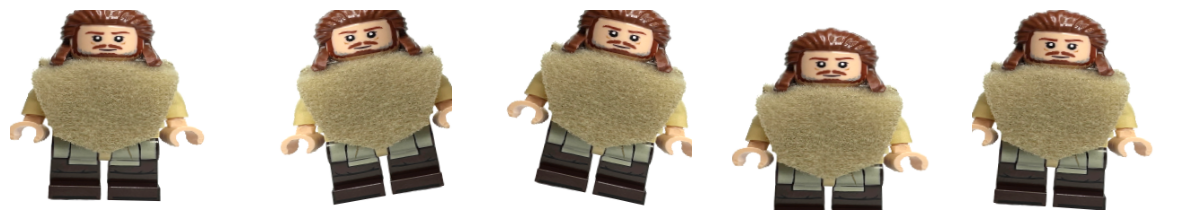

In [18]:
#example of the augmentation
sample_img_path = os.path.join(IMAGE_DIR, train_df['img_local_path'].iloc[0])
img = tf.keras.preprocessing.image.load_img(sample_img_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape) 

plt.figure(figsize=(15, 5))
i = 0
for batch in train_datagen.flow(img_array, batch_size=1):
    plt.subplot(1, 5, i + 1)
    plt.imshow(tf.keras.preprocessing.image.array_to_img(batch[0]))
    plt.axis('off')
    i += 1
    if i % 5 == 0:
        break
plt.show()

In [8]:
# Grab one batch of data
x, y = next(train_generator)

print(f"Max pixel value: {np.max(x)}") 
print(f"Any NaNs in images? {np.isnan(x).any()}")
print(f"Any NaNs in labels? {np.isnan(y).any()}")

Max pixel value: 1.0
Any NaNs in images? False
Any NaNs in labels? False


MultiLabelBinarizer creates a matrix where every unique theme becomes a column and an image belonging to it, gets a 1 in the column, else 0
merges original image file paths with the theme matrix 
converts img_local_path to strings and removes rows where the path is NaN & labels are converted to float32

check for NaNs and any value other than 0 / 1

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

mlb = MultiLabelBinarizer()
theme_matrix = mlb.fit_transform(df['themes'])

theme_df = pd.DataFrame(theme_matrix, columns=mlb.classes_)

df_final = pd.concat([df[['img_local_path']], theme_df], axis=1)
MULTI_LABELS = list(mlb.classes_)

df_final['img_local_path'] = df_final['img_local_path'].astype(str)
df_final = df_final[df_final['img_local_path'] != 'nan']

In [10]:
df_final[MULTI_LABELS] = df_final[MULTI_LABELS].fillna(0)

df_final[MULTI_LABELS] = df_final[MULTI_LABELS].astype('float32')

nan_count = df_final[MULTI_LABELS].isnull().sum().sum()
print(f"Total NaNs in labels: {nan_count}") 

invalid_values = df_final[~df_final[MULTI_LABELS].isin([0, 1]).all(axis=1)]
print(f"Rows with invalid label values: {len(invalid_values)}")

Total NaNs in labels: 0
Rows with invalid label values: 0


Pick up themes and set up a model which trains on those
MobileNetV2  - lightweight, high-performance model trained on ImageNet 
include_top=False - removing the 1,000-class classifier to iclude the Lego-specific one
trainable = False - freeze the base and keep all the knowledge regarding how to detect edges and shapes to enable faster training

Custom Classifier for LEGO
GlobalAveragePooling2D() - converts the complex 2D spatial maps from the base model into a flat single 1D vector
BatchNormalization() - scales the data to prevent one feature (bright colour or sharp edge) from becoming too important and helps the model train faster and be less sensitive to different lighting 
Dropout(0.3) - randomly turns off 30% of the neurons forcing the model to find multiple ways to identify themes to prevent overfitting

Sigmoid - gives every theme a score between 0 and 1 independently to help with multi-label prediction

In [11]:
from tensorflow.keras import layers, models

num_labels = len(MULTI_LABELS) 

base_model2 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False 

model_multi = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_labels, activation='sigmoid') 
])

model_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1), 
    metrics=['binary_accuracy', tf.keras.metrics.Precision(name='precision')]
)


Binary Crossentropy as Loss
each theme becomes an independent Yes/No question and the predicted probability of each is compared to 0/1 and penalized based on distance btw them
Label Smoothing prevents overfitting by asking model to aim for 0.9 instead of 1 to cater for ambiguity.

a better option which I try out later could be Focal Loss since it down-weights easy themes forcing model to focus on the hard ones 

Binary Accuracy as Metric
percentage of total Yes/No guesses that were correct across all classes
but i may be misleading because just predicting null can give high accuracy
Precision compares of all predictions for one theme, in how many cases was the model actually right and it is better than accuracy

a better option could be F1-score because it is the harmonic mean of Precision and Recall and so forces the model to balance both
ADAM - to help guide the optimisation of model weights during training

In [12]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(df_final, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

train_generator = train_datagen.flow_from_dataframe( #maps names in JSON to the files
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MULTI_LABELS,
    target_size=IMG_SIZE, #every image same dimensions (224,224)
    batch_size=32, #look at 32 images at a time 
    class_mode="other" #convert labels into One-Hot Encoded vectors
)

#for fitting the model
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MULTI_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other"
)

# for F1, Confusion Matrix, and Predictions
eval_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MULTI_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False  
)

# for final F1, Confusion Matrix, and Predictions
test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MULTI_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False  
)

Found 12483 validated image filenames.
Found 3121 validated image filenames.
Found 3121 validated image filenames.
Found 1734 validated image filenames.


ReduceLROnPlateau - monitors val_loss and when it stops improving for 2 epochs, it cuts the learning rate in half (factor=0.5).
As the model gets closer to its best performance, the step-size in gradient descent is made smaller to avoid "vershooting the optimal solution. 

EarlyStopping - stops the training if val_loss doesn't improve for 4 epochs to prevent overfitting by keeping the version that performed best on the validation data.

In [40]:
history_multi = model_multi.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
    ]
)

Epoch 1/15
391/391 [==============================] - 529s 1s/step - loss: 0.8241 - binary_accuracy: 0.5436 - precision: 0.0082 - val_loss: 0.6124 - val_binary_accuracy: 0.6888 - val_precision: 0.0098 - lr: 1.0000e-04
Epoch 2/15
391/391 [==============================] - 555s 1s/step - loss: 0.4943 - binary_accuracy: 0.8016 - precision: 0.0110 - val_loss: 0.2917 - val_binary_accuracy: 0.9752 - val_precision: 0.0356 - lr: 1.0000e-04
Epoch 3/15
391/391 [==============================] - 557s 1s/step - loss: 0.2806 - binary_accuracy: 0.9721 - precision: 0.0268 - val_loss: 0.2367 - val_binary_accuracy: 0.9916 - val_precision: 0.2235 - lr: 1.0000e-04
Epoch 4/15
391/391 [==============================] - 553s 1s/step - loss: 0.2487 - binary_accuracy: 0.9888 - precision: 0.0804 - val_loss: 0.2342 - val_binary_accuracy: 0.9922 - val_precision: 0.4122 - lr: 1.0000e-04
Epoch 5/15
391/391 [==============================] - 531s 1s/step - loss: 0.2438 - binary_accuracy: 0.9907 - precision: 0.1519 

Plotting Performance

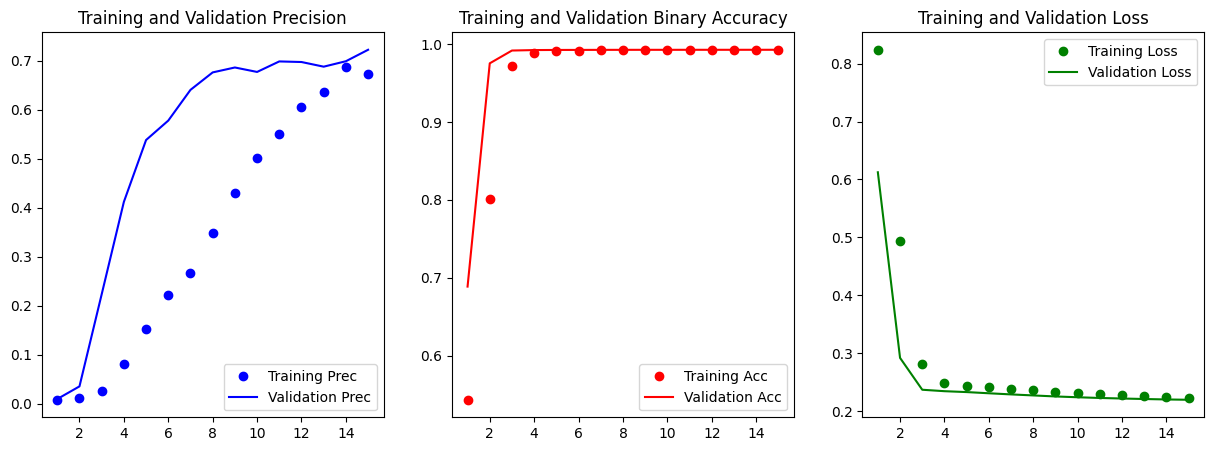

In [41]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['binary_accuracy']
    val_acc = history.history['val_binary_accuracy']
    prec = history.history['precision']
    val_prec = history.history['val_precision']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, prec, 'bo', label='Training Prec')
    plt.plot(epochs, val_prec, 'b', label='Validation Prec')
    plt.title('Training and Validation Precision')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, acc, 'ro', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Binary Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss, 'go', label='Training Loss')
    plt.plot(epochs, val_loss, 'g', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history_multi)

Precision - compares ratio of True Positives to the total number of Positive predictions and it is good that the curves are climbing steadily meaning as the model sees more data, it is learning and becoming more reliable.                                                                            Validation Precision is  slightly higher than Training due to Smoothing as it makes training task slightly harder                                   

Binary Accuracy - compares percentage of total Yes/No guesses that were correct. This can be misleading as an image might have only 2 themes out of 130 and if the model predicts Zero for everything, it ends up with a high accurcay as it is right 128 times.

Training and Validation Loss - compares the Binary Crossentropy error which is what the model is trying to minimize.
The steep drop early on shows the model quickly adapting to the new usecase of Lego and since the train and val losses are converging parallely there is no sign of overfitting which means our earlystopping and dropout (0.3) are working

Fine-Tuning

In [42]:
base_model2.trainable = True

for layer in base_model2.layers[:-60]:
    layer.trainable = False

model_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['binary_accuracy', tf.keras.metrics.Precision(name='precision')]
)

history_finetune = model_multi.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
391/391 [==============================] - 672s 2s/step - loss: 0.2240 - binary_accuracy: 0.9924 - precision: 0.6196 - val_loss: 0.2201 - val_binary_accuracy: 0.9924 - val_precision: 0.5314
Epoch 2/20
391/391 [==============================] - 703s 2s/step - loss: 0.2231 - binary_accuracy: 0.9925 - precision: 0.6654 - val_loss: 0.2196 - val_binary_accuracy: 0.9924 - val_precision: 0.5442
Epoch 3/20
391/391 [==============================] - 693s 2s/step - loss: 0.2225 - binary_accuracy: 0.9925 - precision: 0.6517 - val_loss: 0.2190 - val_binary_accuracy: 0.9925 - val_precision: 0.6064
Epoch 4/20
391/391 [==============================] - 621s 2s/step - loss: 0.2221 - binary_accuracy: 0.9925 - precision: 0.6725 - val_loss: 0.2187 - val_binary_accuracy: 0.9925 - val_precision: 0.6384
Epoch 5/20
391/391 [==============================] - 696s 2s/step - loss: 0.2217 - binary_accuracy: 0.9925 - precision: 0.6690 - val_loss: 0.2184 - val_binary_accuracy: 0.9926 - val_precision: 0.

Loss - sharp decline in both training and validation loss within the first 5 epochs & after epoch 15, the loss curves flatten into a stable plateau
Accuracy - in a sparse multi-label context, this reflects tagging True Negatives (predicting 0 gives high acc anyway & is misleading)


Pre-Fine-Tuning:  loss dropped rapidly but hit a plateau early - the model learning general features common to all LEGO sets
Post-Fine-Tuning: After unfreezing, the Total Loss achieved a new, lower baseline justifying that deeper layers help capture the subtle nuances of specific themes like Ninjago or Star Wars

Pre-Fine-Tuning: Precision and F1-score were volatile and significantly lower. The model was making many "noisy" guesses.
Post-Fine-Tuning: There is a massive, steady climb in Total Precision

In both phases, the validation accuracy and precision consistently tracked or exceeded the training metrics

Quick Spot Check

In [45]:
x_batch, y_batch = next(eval_generator)
gen_labels = [MULTI_LABELS[j] for j, val in enumerate(y_batch[0]) if val == 1]

img_path = eval_generator.filenames[0]
df_row = val_df[val_df['img_local_path'] == img_path].iloc[0]
df_labels = [col for col in MULTI_LABELS if df_row[col] == 1]

print(f"Generator sees: {gen_labels}")
print(f"Dataframe has:  {df_labels}")
assert gen_labels == df_labels, "ALIGNMENT ERROR: Labels do not match!"

Generator sees: ['Star Wars']
Dataframe has:  ['Collectable Minifigures']


AssertionError: ALIGNMENT ERROR: Labels do not match!

In [48]:
#match the model's output neurons
val_df_fixed = val_df[['img_local_path'] + list(MULTI_LABELS)]

eval_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MULTI_LABELS, 
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False
)

eval_generator.reset()
x_batch, y_batch = next(eval_generator)
gen_labels = [MULTI_LABELS[j] for j, val in enumerate(y_batch[0]) if val == 1]

img_path = eval_generator.filenames[0]
df_row = val_df_fixed[val_df_fixed['img_local_path'] == img_path].iloc[0]
df_labels = [col for col in MULTI_LABELS if df_row[col] == 1]

print(f"Generator sees: {gen_labels}")
print(f"Dataframe has:  {df_labels}")
assert gen_labels == df_labels, "ALIGNMENT ERROR!"

Found 3121 validated image filenames.
Generator sees: ['Collectable Minifigures']
Dataframe has:  ['Collectable Minifigures']


1/1 [==============================] - 1s 733ms/step


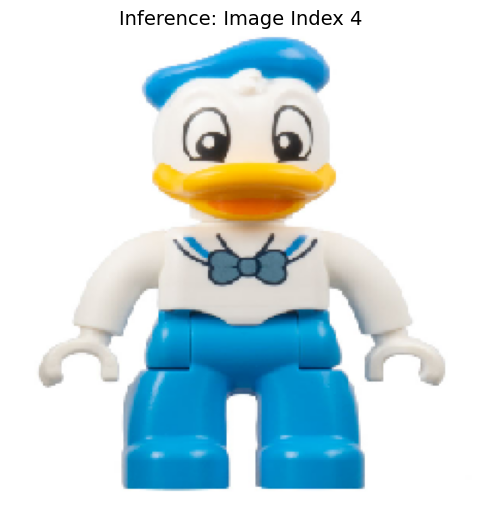

Top 5 Model Predictions
Duplo: 36.21% [MATCH]
Education: 12.43% [MATCH]
Ninjago: 8.99% 
City: 8.59% 
Gear: 7.39% 

Actual Labels: ['Duplo']


In [67]:
x_batch, y_batch = next(eval_generator)
preds = model_multi.predict(x_batch)

i = 4
top_indices = np.argsort(preds[i])[-5:][::-1] 

def deprocess_img(img_array):
    img = img_array.copy()
    if img.min() < 0 or img.max() <= 1.0:
        img = (img - img.min()) / (img.max() - img.min()) * 255
    return img.astype('uint8')

plt.figure(figsize=(8, 6))
plt.imshow(deprocess_img(x_batch[i])) # Use the deprocessed image 
plt.title(f"Inference: Image Index {i}", fontsize=14)
plt.axis('off')
plt.show()

print(f"Top 5 Model Predictions")
for idx in top_indices:
    status = "[MATCH]" if preds[i][idx] > 0.10 else ""
    print(f"{MULTI_LABELS[idx]}: {preds[i][idx]:.2%} {status}")

actuals = [MULTI_LABELS[j] for j, val in enumerate(y_batch[i]) if val == 1]
print(f"\nActual Labels: {actuals}")



1/1 [==============================] - 0s 104ms/step


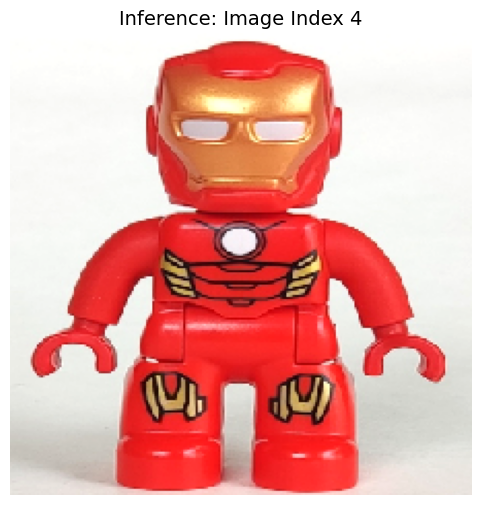

Top 5 Model Predictions
Duplo: 21.46% [MATCH]
Star Wars: 15.68% [MATCH]
Education: 9.78% 
Jurassic World: 9.17% 
Harry Potter: 9.00% 

Actual Labels: ['Duplo']


In [109]:
x_batch, y_batch = next(val_generator)
preds = model_multi.predict(x_batch)

i = 4
top_indices = np.argsort(preds[i])[-5:][::-1] 

def deprocess_img(img_array):
    img = img_array.copy()
    if img.min() < 0 or img.max() <= 1.0:
        img = (img - img.min()) / (img.max() - img.min()) * 255
    return img.astype('uint8')

plt.figure(figsize=(8, 6))
plt.imshow(deprocess_img(x_batch[i])) 
plt.title(f"Inference: Image Index {i}", fontsize=14)
plt.axis('off')
plt.show()

print(f"Top 5 Model Predictions")
for idx in top_indices:
    status = "[MATCH]" if preds[i][idx] > 0.10 else ""
    print(f"{MULTI_LABELS[idx]}: {preds[i][idx]:.2%} {status}")

actuals = [MULTI_LABELS[j] for j, val in enumerate(y_batch[i]) if val == 1]
print(f"\nActual Labels: {actuals}")

Grabs a random batch of 32 images from the validation set and runs those through the model to get probability scores for all themes and then displays the 5 themes with highest scores against the one ground-truth label

actual label is 'Duplo', & predictions were 'Duplo' (22%) and 'StarWars' (16%) or education as shown above 

failure could be due to visual overlap between the two as the pieces  have space-themed units which are identical to the star wars sets
the highest probability is only 22% which means that with a 50% threshold we would have gotten no prediction

so the miss makes sense semantically and this makes clear what challenges we have - overlap and the model not being confident enough in its predictions

In [69]:
from sklearn.metrics import f1_score
eval_generator.reset()
y_probs = model_multi.predict(eval_generator)

y_true = eval_generator.labels 

threshold = 0.5
y_pred = (y_probs > threshold).astype(int)

samples_f1 = f1_score(y_true, y_pred, average='samples')
print(f"Overall Samples-Average F1-Score: {samples_f1:.4f}")

98/98 [==============================] - 66s 664ms/step
Overall Samples-Average F1-Score: 0.0688


C:\Users\athul\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


model outputs a probability for every themes for every image in the validation set with threshold set at 50% and then calculates an avg F1-score 

0.70% score indicates a mismatch between model confidence and the threshold because as seen above in the spot check, the individual predictions for the labels are not very confident with the highest being 37% which in this threhold setting would have led to 0 prediction
since most images have 0 preds, the recall is nearly 0 crashing the F1

warning because images with 1 label is being predicted as having 0 labels due to low confidence pred probs making the F1 calculation have a division by zero leading to ill-defined warning

hence we need to implement a Per-Class Optimal Thresholding

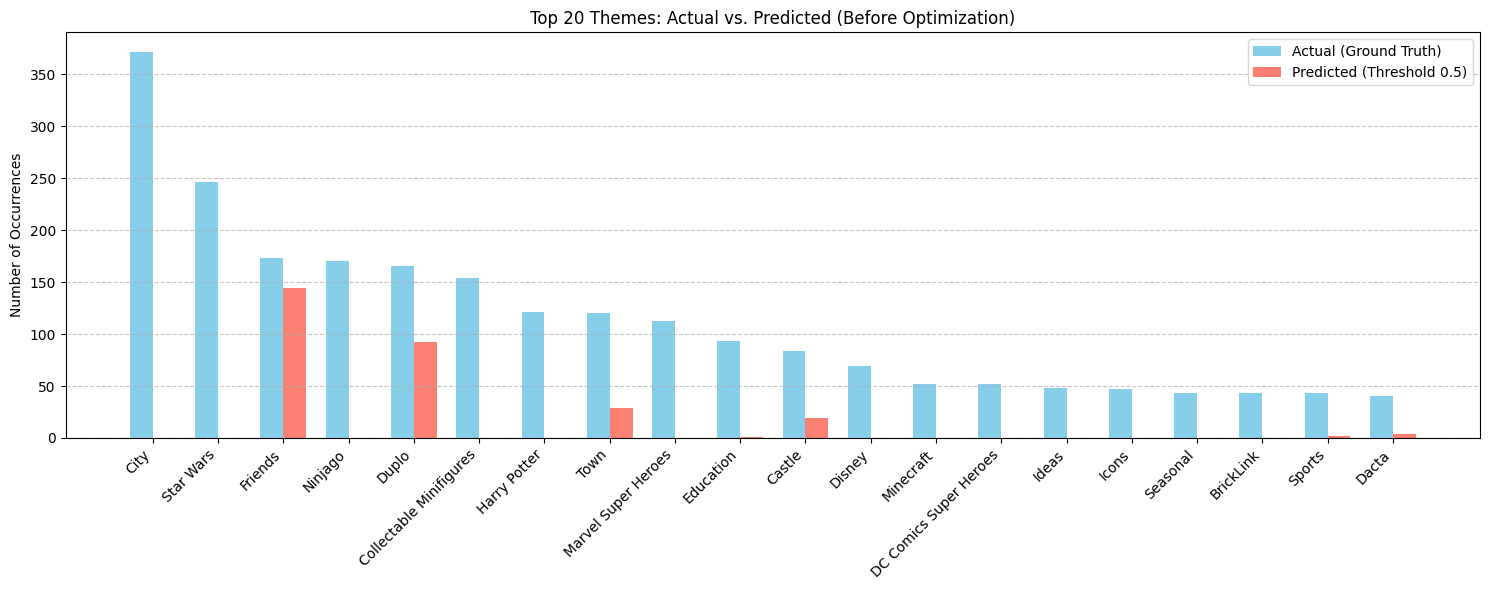

In [72]:
def plot_label_distribution(y_true, y_pred, labels, top_n=20):
    true_counts = np.sum(y_true, axis=0)
    pred_counts = np.sum(y_pred, axis=0)
    
    indices = np.argsort(true_counts)[::-1][:top_n]
    
    plt.figure(figsize=(15, 6))
    x = np.arange(len(indices))
    width = 0.35
    
    plt.bar(x - width/2, true_counts[indices], width, label='Actual (Ground Truth)', color='skyblue')
    plt.bar(x + width/2, pred_counts[indices], width, label='Predicted (Threshold 0.5)', color='salmon')
    
    plt.xticks(x, [labels[i] for i in indices], rotation=45, ha='right')
    plt.ylabel('Number of Occurrences')
    plt.title(f'Top {top_n} Themes: Actual vs. Predicted (Before Optimization)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_label_distribution(y_true, y_pred, MULTI_LABELS)

For 16 out of the top 20 themes (including high-volume categories like City, Star Wars, and Ninjago), the predicted bars are virtually non-existent although the model has learned these themes, its internal confidence for them rarely crosses the arbitrary 50% line

Only Friends,Duplo, Town and Town show visible bars at this threshold-have extremely distinct visual signatures that the model can identify with high certainty 

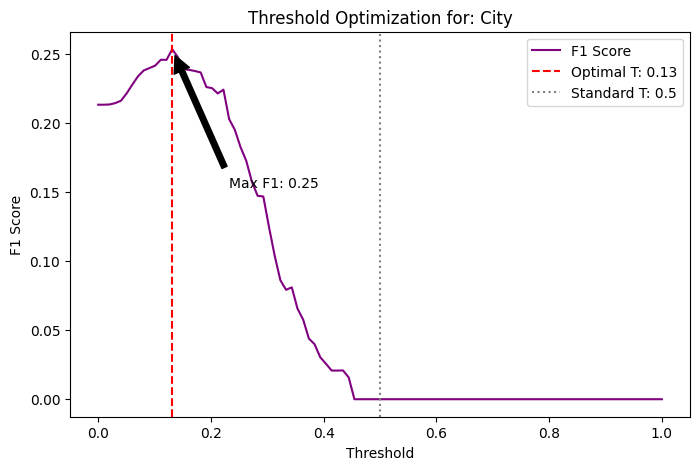

In [76]:
from sklearn.metrics import f1_score

def plot_threshold_search(y_true, y_probs, class_idx, label_name):
    thresholds = np.linspace(0, 1, 100)
    f1_scores = []
    
    for t in thresholds:
        preds = (y_probs[:, class_idx] >= t).astype(int)
        f1_scores.append(f1_score(y_true[:, class_idx], preds))
        
    best_t = thresholds[np.argmax(f1_scores)]
    max_f1 = max(f1_scores)
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores, label='F1 Score', color='purple')
    plt.axvline(best_t, color='red', linestyle='--', label=f'Optimal T: {best_t:.2f}')
    plt.axvline(0.5, color='gray', linestyle=':', label='Standard T: 0.5')
    
    plt.title(f'Threshold Optimization for: {label_name}')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.annotate(f'Max F1: {max_f1:.2f}', xy=(best_t, max_f1), xytext=(best_t+0.1, max_f1-0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    plt.show()

sw_idx = MULTI_LABELS.index('City')
plot_threshold_search(y_true, y_probs, sw_idx, 'City')

here it is clear that a better F1 score is guaranteed with a change in threshold instead of using the manual 0.5

In [79]:
generator_order = list(val_df_fixed.columns[1:]) 

if generator_order == list(MULTI_LABELS):
    print("ALIGNMENT VERIFIED")
    
    from sklearn.metrics import classification_report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=MULTI_LABELS, 
        zero_division=0
    )
    print(report)
else:
    print("❌ ALIGNMENT ERROR!")
    print(f"DF Columns (first 3): {actual_df_cols[:3]}")
    print(f"List Labels (first 3): {list(MULTI_LABELS)[:3]}")

✅ ALIGNMENT VERIFIED: Your DataFrame columns match your Label List.
                              precision    recall  f1-score   support

                   4 Juniors       0.00      0.00      0.00         4
             Action Wheelers       0.00      0.00      0.00         2
             Advanced models       0.00      0.00      0.00        22
                 Adventurers       0.00      0.00      0.00        12
                      Agents       0.00      0.00      0.00         5
                  Alpha Team       0.00      0.00      0.00         6
             Animal Crossing       0.00      0.00      0.00         6
                Aqua Raiders       0.00      0.00      0.00         4
                    Aquazone       0.00      0.00      0.00         4
                    Assorted       0.00      0.00      0.00         2
                    Atlantis       0.00      0.00      0.00         6
                      Avatar       0.00      0.00      0.00         7
  Avatar: The Last Ai

As we saw earlier, the model's confidence for the correct label is often around 30%–40% meaning with a 0.5 threshold, every guess became a non-prediction

Duplo, Friends, and Town have scores above zero since these have colourful, visually distinct bricks which led to the model having above 0.5 confidence while predicting these as compared to sets which have more visual overlap 

For Town - even when model did predict it was only right 12% of the time, missing 88% (recall - 12) of the actual sets again proving that a global threshold of 0.5 is not a good idea for such a large imbalanced multilabel problem 

Micro Avg (0.01 F1) - across all 3,260 labels in val set, the model identified only about 1% of them.
Macro Avg (0.00 F1) - treats labels with 2 samples the same ones with 400 samples and since the model failed acrpss the board, it is 0
Samples Avg (0.00 F1) - average performance per image

Multi-label Sparsity - in a high-dimensional space, the sigmoid outputs are distributed across many categories, rarely exceeding 50% for any single class. While the model correctly identifies patterns, the 0.5 cutoff leads to a total collapse of Recall.

Trying different thresholds - Precision-Recall Tradeoff

In [80]:
y_pred_low = (y_probs > 0.1).astype(int)
print(classification_report(y_true, y_pred_low, target_names=MULTI_LABELS, zero_division=0))

                              precision    recall  f1-score   support

                   4 Juniors       0.00      0.00      0.00         4
             Action Wheelers       0.00      0.00      0.00         2
             Advanced models       0.08      0.14      0.10        22
                 Adventurers       0.00      0.00      0.00        12
                      Agents       0.00      0.00      0.00         5
                  Alpha Team       0.00      0.00      0.00         6
             Animal Crossing       0.00      0.00      0.00         6
                Aqua Raiders       0.00      0.00      0.00         4
                    Aquazone       0.00      0.00      0.00         4
                    Assorted       0.00      0.00      0.00         2
                    Atlantis       0.00      0.00      0.00         6
                      Avatar       0.00      0.00      0.00         7
  Avatar: The Last Airbender       0.00      0.00      0.00         0
                   

At 0.5 - Recall was 0.00 and @ 0.1 recall for major themes has increased, also it is now picking up a lot of themes it completely avoided predicting on earlier due to high threshold - Bionicle, Basic etc

City -> 0.00 to 0.14 (model finds 90% of all City sets)
Star Wars -> 0.00 to 0.10 (model finds 73% of Star Wars sets)
Ninjago -> 0.00 to 0.07 (model finds 52% of Ninjago sets)

lowering threshold has unlocked model’s ability to label the data however, as Recall went up, Precision went down.
City - while the model found 90% of the City sets, only 24% of the guesses were actually correct 

Micro Avg F1 (0.17) - heavily influenced by the big classes and since model is doing better on them now, this has improved 
Macro Avg F1 (0.06) - remians low because most themes have 0.00 scores because it can't identify the rarer themes

In [81]:
from sklearn.metrics import hamming_loss
print(f"Hamming Loss: {hamming_loss(y_true, y_pred):.4f}")

Hamming Loss: 0.0074


Hamming Loss - measures the global error rate (both 0s and 1s) = fraction of total labels that are incorrectly predicted
Out of every 1,000 predictions, model is wrong only 7.5 times
Most LEGO images only belong to 1 or 2 themes leading to almost 128 Zeros 
a model that predicts 0 for everything (@ 0.5 threshold), it gets 128 correct -> low Hamming Loss 

total fraction of misclassified labels across all themes is less than 1% --> a reflection of the sparse nature of the dataset 
model is not prone to high False Positive rates

Different Approach - For a more accurate labelling, keep only those which have atleast 30 images tagged to it and add more augmentation

In [13]:
theme_counts = df_final[MULTI_LABELS].sum().sort_values(ascending=False)

#Pick only themes with 30+ images
MAJOR_LABELS = theme_counts[theme_counts >= 30].index.tolist()

print(f"Reducing from {len(MULTI_LABELS)} labels to {len(MAJOR_LABELS)} major labels.")
print(f"Remaining themes: {MAJOR_LABELS}")

df_filtered = df_final[['img_local_path'] + MAJOR_LABELS].copy()
df_filtered = df_filtered[df_filtered[MAJOR_LABELS].sum(axis=1) > 0]

Reducing from 136 labels to 75 major labels.
Remaining themes: ['City', 'Star Wars', 'Ninjago', 'Friends', 'Duplo', 'Collectable Minifigures', 'Marvel Super Heroes', 'Town', 'Harry Potter', 'Castle', 'Education', 'Disney', 'DC Comics Super Heroes', 'Icons', 'Ideas', 'BrickLink', 'Promotional', 'Dacta', 'Minecraft', 'Sports', 'Super Mario', 'Seasonal', 'Gear', 'Monkie Kid', 'Space', 'Creator', 'Legends of Chima', 'Nexo Knights', 'Pirates', 'Speed Champions', 'Creator Expert', 'Juniors', 'Miscellaneous', 'Jurassic World', 'Trains', 'Games', 'Belville', 'Dreamzzz', 'Advanced models', 'The LEGO Batman Movie', 'The LEGO Ninjago Movie', 'Fabuland', 'The LEGO Movie 2', 'Explore', 'Racers', 'The LEGO Movie', 'Hidden Side', 'Dimensions', 'The Hobbit', 'Elves', 'Indiana Jones', 'Basic', 'Cars', 'Teenage Mutant Ninja Turtles', 'Adventurers', 'The Lord of the Rings', 'Vidiyo', 'Bricks and More', 'Books', 'Pirates of the Caribbean', 'Studios', 'Bionicle', 'LEGOLAND', 'Unikitty', 'Ultra Agents', 'DC

identify and filter for themes that have at least 30 example images to find a reliable patterns and drop the noise by deleting any image that only belonged to the rare themes identified
thus the model no longer wastes energy trying to figure out what a theme with only 2 images looks like hopefully making the gradient updates more consistent and the F1 score more reliable 

try and make the model 90% right about the top 30 themes rather than being 5% right about 130 themes as we have a dataset where over 70% of classes contained fewer than 10 samples and so reducing the matrix from 136 to 75 labels helps improve the realibility of feature extractors

In [14]:
train_val_df2, test_df2 = train_test_split(df_filtered, test_size=0.1, random_state=42)
train_df2, val_df2 = train_test_split(train_val_df2, test_size=0.2, random_state=42)

print(f"Training set: {len(train_df2)}")  
print(f"Validation set: {len(val_df2)}")  
print(f"Test set: {len(test_df2)}") 

#for fitting the model
val_generator2 = val_datagen.flow_from_dataframe(
    dataframe=val_df2,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other"
)

val_df_fixed = val_df2[['img_local_path'] + list(MAJOR_LABELS)]

eval_generator2 = val_datagen.flow_from_dataframe(
    dataframe=val_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS, 
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False
)


# for F1, Confusion Matrix, and Predictions
test_generator2 = val_datagen.flow_from_dataframe(
    dataframe=test_df2,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False  
)

Training set: 11907
Validation set: 2977
Test set: 1654
Found 2977 validated image filenames.
Found 2977 validated image filenames.
Found 1654 validated image filenames.


Find labels which need more images for better prediction - Multilabel Random Oversampling 

In [15]:
counts = df_filtered[MAJOR_LABELS].sum()
needed = (50 - counts).clip(lower=0)

rare_labels = needed[needed > 0].index.tolist()
df_to_augment = df_filtered[df_filtered[rare_labels].sum(axis=1) > 0]

print(f"{len(df_to_augment)} images that need augmentation.")

748 images that need augmentation.


out of the pruned labels, calculate how many samples are needed for each label so that it has atleast 50 images to train on and then clone the existing images from the current pool so the model sees enough of them to learn how to differentiate them 
this helps the model generalise better rather than getting very good at detecting the classes it sees more of
to prevent the model learning or memorising the specific cloned images, we augment them to make them look slightly different

helps ensures that the Gradient Descent process receives sufficient signal from minority classes and to prevent overfitting pair with Image Augmentation so the duplicated samples have unique visual permutations during each training epoch

Make dataset more balanced by adding in more images belonging to themes which are under-represented

In [16]:
def balance_multi_label_data(df, labels, target_count=50):
    df_resampled = df.copy()
    
    for label in labels:
        current_count = df_resampled[label].sum()
        if current_count < target_count:
            n_needed = int(target_count - current_count)
            available_rows = df[df[label] == 1]
            resampled_rows = available_rows.sample(n_needed, replace=True)
            df_resampled = pd.concat([df_resampled, resampled_rows], axis=0)
            
    return df_resampled

df_balanced = balance_multi_label_data(train_df2, MAJOR_LABELS, target_count=50)
print(f"New dataset size: {len(df_balanced)}")

New dataset size: 12414


Train on top 75 labels

In [17]:
MAJOR_LABELS = [
    'City', 'Star Wars', 'Ninjago', 'Friends', 'Duplo', 'Collectable Minifigures', 
    'Marvel Super Heroes', 'Town', 'Harry Potter', 'Castle', 'Education', 'Disney', 
    'DC Comics Super Heroes', 'Icons', 'Ideas', 'BrickLink', 'Promotional', 'Dacta', 
    'Minecraft', 'Sports', 'Super Mario', 'Seasonal', 'Gear', 'Monkie Kid', 'Space', 
    'Creator', 'Legends of Chima', 'Nexo Knights', 'Pirates', 'Speed Champions', 
    'Creator Expert', 'Juniors', 'Miscellaneous', 'Jurassic World', 'Trains', 'Games', 
    'Belville', 'Dreamzzz', 'Advanced models', 'The LEGO Batman Movie', 
    'The LEGO Ninjago Movie', 'Fabuland', 'The LEGO Movie 2', 'Explore', 'Racers', 
    'The LEGO Movie', 'Hidden Side', 'Dimensions', 'The Hobbit', 'Elves', 
    'Indiana Jones', 'Basic', 'Cars', 'Teenage Mutant Ninja Turtles', 'Adventurers', 
    'The Lord of the Rings', 'Vidiyo', 'Bricks and More', 'Books', 
    'Pirates of the Caribbean', 'Studios', 'Bionicle', 'LEGOLAND', 'Unikitty', 
    'Ultra Agents', 'DC Super Hero Girls', 'Agents', 'Technic', 'Despicable Me', 
    'Sonic the Hedgehog', 'World City', 'SpongeBob SquarePants', 'Power Miners', 
    'Alpha Team', 'Wicked'
]

train_df2, _ = train_test_split(df_balanced, test_size=0.1) # We just need the full balanced set for training

train_datagen2 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator2 = train_datagen2.flow_from_dataframe( #maps names in JSON to the files
    dataframe=train_df2,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=IMG_SIZE, #every image same dimensions (224,224)
    batch_size=32, #look at 32 images at a time 
    class_mode="other" #convert labels into One-Hot Encoded vectors
)

#keep validation and test from earlier since in real-life rare images will be present and they should not be oversampled while evaluating the model

Found 11172 validated image filenames.


partitioning the dataset prior to oversampling, prevents data leakage by ensuring the model is evaluated on unseen data
random split on a large enough dataset preserves the distribution of major themes for evaluation
test the model on the original distribution for an honest evaluation since a user is more likely to upload a City set than a Wicked set in real life
adding zoom_range and brightness_range helps further differentiate the cloned images in the training set

Add more drop-out to account for heavier augmentation to prevent over-fitting

In [18]:
base_model2 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False 

callbacks2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=4, 
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'filter_lego_model.h5', 
        save_best_only=True
    )
]

model_balanced = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.35), # Stronger dropout for augmented data
    layers.Dense(75, activation='sigmoid') 
])

model_balanced.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

1/1 [==============================] - 1s 726ms/step
--- Top 5 Model Predictions for Image 3 ---
Duplo: 64.62%
Education: 16.40%
Ninjago: 6.87%
Star Wars: 6.16%
Dacta: 5.15%

Actual Labels: ['Duplo']


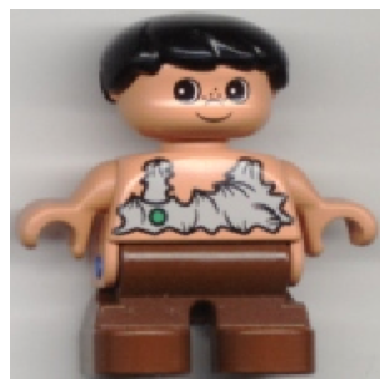

In [98]:
x_test, y_test = next(eval_generator2)
preds = model_balanced.predict(x_test)

idx = 3

i_image = idx 

print(f"--- Top 5 Model Predictions for Image {i_image} ---")
top_indices = np.argsort(preds[i_image])[-5:][::-1]

for i in top_indices:
    print(f"{MAJOR_LABELS[i]}: {preds[i_image][i]:.2%}")

actuals = [MAJOR_LABELS[i] for i, val in enumerate(y_test[i_image][:len(MAJOR_LABELS)]) if val == 1]

print(f"\nActual Labels: {actuals}")

plt.imshow((x_test[i_image] - x_test[i_image].min()) / (x_test[i_image].max() - x_test[i_image].min()))
plt.axis('off')
plt.show()

massive delta between the top prediction (651%) and the runner-up (16%) --> more confident about themes and is able to distinguish better

since we have been using the validation results to change the learning rate, the architecture, the threshold and for these spot checks - it is optimised for these images and hence the validation F1 (0.23) is probably slightly higher than what what is possible on new data

In [99]:
test_df_fixed = test_df2[['img_local_path'] + list(MAJOR_LABELS)]

# for F1, Confusion Matrix, and Predictions
test_generator2 = val_datagen.flow_from_dataframe(
    dataframe=test_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="other",
    shuffle=False  
)

def evaluate_on_test(model, generator, labels, threshold=0.10):
    generator.reset()
    y_probs = model.predict(generator)
    y_true = generator.labels
    y_pred = (y_probs > threshold).astype(int)
    
    print("TEST METRICS")
    print(f"Hamming Loss: {hamming_loss(y_true, y_pred):.4f}")
    print(f"Samples F1-Score: {f1_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
    print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

evaluate_on_test(model_balanced, test_generator2, MAJOR_LABELS)

Found 1654 validated image filenames.
52/52 [==============================] - 36s 679ms/step
TEST METRICS
Hamming Loss: 0.0379
Samples F1-Score: 0.2215
Macro F1-Score: 0.1117

Classification Report:
                              precision    recall  f1-score   support

                        City       0.15      0.82      0.25       199
                   Star Wars       0.10      0.38      0.16       145
                     Ninjago       0.10      0.30      0.15        94
                     Friends       0.47      0.85      0.61        87
                       Duplo       0.34      0.64      0.44        86
     Collectable Minifigures       0.09      0.24      0.13        87
         Marvel Super Heroes       0.07      0.22      0.10        60
                        Town       0.24      0.79      0.37        70
                Harry Potter       0.06      0.22      0.10        60
                      Castle       0.19      0.66      0.29        41
                   Education 

Global Metrics 
Hamming Loss (0.03) - of all possible themes, the model is correct about 96.7% of individual label slots
Samples F1 (0.189) - for an average image, the balance between Precision and Recall is roughly 19%
Macro F1 (0.1) - averages the performance across all classes equally and is lower because long-tail themes are harder to predict 

Friends (F1: 0.47) & Duplo (F1: 0.34) - very distinct color palettes and shapes, which the model captured perfectly
City (Recall: 0.82) - caught 82% of all City sets in the test set but lower precision (0.15) shows it is overeager with it
LEGOLAND (F1: 0.50) & SpongeBob SquarePants (F1: 0.67) - when the visual features are unique, the model is incredibly accurate.

Classes with 0.00 (Wicked, Agents) - due to Feature Overlap, even with oversampling, it is too visually diverse or scarce

The disparity between Macro and Micro averages reflects the inherent difficulty of the Long-Tail distribution, but the overall system maintains a clean prediction set with minimal false positives (low Hamming Loss)

Further Enhancement

Standard Crossentropy treats every error the same whereas Focal Loss down-weights easy examples and focuses the gradient on hard examples 
addresses the class imbalance directly by weighting the minority classes more than the majority

trying to move from MobileNet (optimized for speed) to EfficientNet (optimized for accuracy) which scales depth, width, and resolution simultaneously
prioritizing model performance over raw inference speed
Standard models usually just get deeper but EfficientNet scales width, depth, and resolution simultaneously via a compound coefficient helping it capture both fine textures and global structures more effectively 
uses Squeeze-and-Excitation blocks (self-attention mechanism) allows the model to prioritize the most important channels for a specific label
produces a more descriptive feature map, dense layer has better raw material to work with, leading to higher Precision and Recall

10 Most Frequent Themes
City                       1308.0
Star Wars                   942.0
Ninjago                     598.0
Friends                     549.0
Duplo                       524.0
Collectable Minifigures     504.0
Town                        472.0
Marvel Super Heroes         458.0
Harry Potter                433.0
Education                   305.0
dtype: float32

 10 Least Frequent Themes
Pirates of the Caribbean    45.0
Despicable Me               44.0
Sonic the Hedgehog          44.0
Indiana Jones               44.0
LEGOLAND                    44.0
The Lord of the Rings       44.0
Books                       43.0
Vidiyo                      43.0
Elves                       43.0
Bricks and More             42.0
dtype: float32


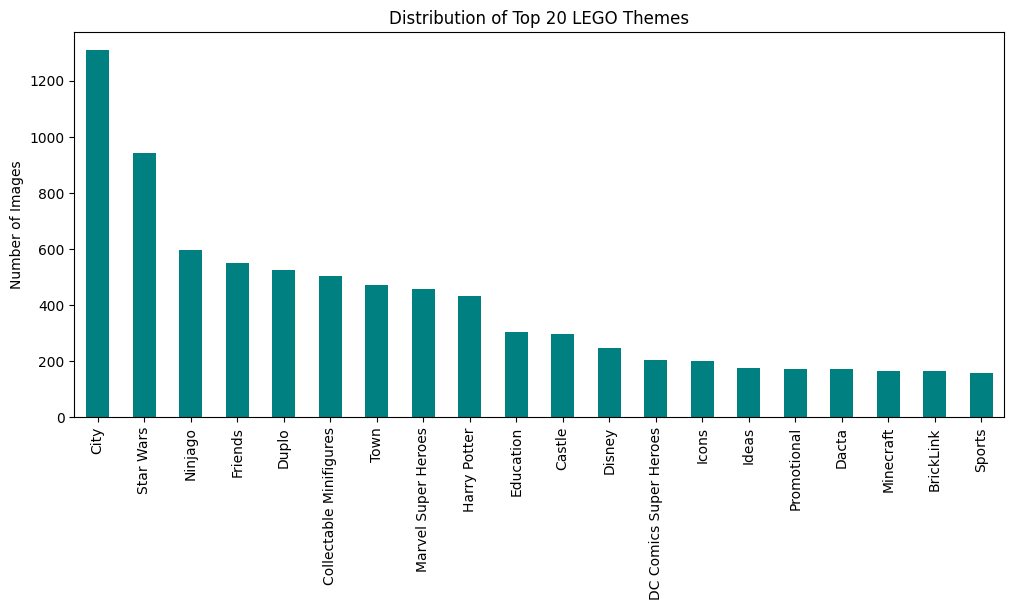

In [19]:
counts = train_df2[MAJOR_LABELS].sum().sort_values(ascending=False)

print("10 Most Frequent Themes")
print(counts.head(10))

print("\n 10 Least Frequent Themes")
print(counts.tail(10))

counts.head(20).plot(kind='bar', figsize=(12, 5), color='teal')
plt.title("Distribution of Top 20 LEGO Themes")
plt.ylabel("Number of Images")
plt.show()

since there is a lot of variation in concentration of labels, we use the iterstrat library to ensure that the distribution of the 75 themes remains consistent across your Train, Validation, and Test sets.

hence, even the rarest labels are represented in the 10% test set and 18% validation set in the same proportion they appear in the total dataset. This ensures AUC and F1 scores are statistically valid.

In [125]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

labels_list = list(MAJOR_LABELS)

# separate 10% for the TEST set
msss_test = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

X = df_final.index.values
y = df_final[labels_list].values

for train_val_idx, test_idx in msss_test.split(X, y):
    df_train_val = df_final.iloc[train_val_idx].copy()
    df_test = df_final.iloc[test_idx].copy()

# Train (~72%), Eval (~18%), Test (10%)
X_tv = df_train_val.index.values
y_tv = df_train_val[labels_list].values

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in msss_val.split(X_tv, y_tv):
    train_df = df_train_val.iloc[train_idx].copy()
    val_df = df_train_val.iloc[val_idx].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(df_test)}")

Train: 12483 | Val: 3121 | Test: 1734


preprocess_input - scales pixel values to the range the EfficientNet model was trained on
interpolation='lanczos'-resampling method to ensure that when images are resized (260*260)fine details are preserved better than bilinear interpolation

In [69]:
from tensorflow.keras.applications.efficientnet import preprocess_input
MAJOR_LABELS = list(MAJOR_LABELS)

train_datagen2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0 
)


base_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator3 = train_datagen2.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    interpolation='lanczos',
    class_mode='other',
    validate_filenames=True
)

val_generator3 = base_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    interpolation='lanczos',
    class_mode='other'
)

val_df_fixed = val_df[['img_local_path'] + list(MAJOR_LABELS)]

eval_generator3 = base_datagen.flow_from_dataframe(
    dataframe=val_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS, 
    target_size=(260, 260),
    batch_size=16,
    class_mode="other",
    interpolation='lanczos',
    shuffle=False
)

test_df_fixed = df_test[['img_local_path'] + list(MAJOR_LABELS)]

# for F1, Confusion Matrix, and Predictions
test_generator3 = base_datagen.flow_from_dataframe(
    dataframe=test_df_fixed,
    directory=IMAGE_DIR,
    x_col="img_local_path",
    y_col=MAJOR_LABELS,
    target_size=(260, 260),
    batch_size=16,
    class_mode="other",
    interpolation='lanczos',
    shuffle=False  
)

Found 12483 validated image filenames.
Found 3121 validated image filenames.
Found 3121 validated image filenames.
Found 1734 validated image filenames.


Backbone (Layers 0–336) - Mobile Inverted Residual Bottleneck blocks
Depthwise Convolutions - model looks at each channel separately eg Layer 8
Squeeze-and-Excitation (SE) (Layers 11–15) - helps the model decide which part of the image is most important 
Freeze the first 300 layers to extract generic features like edges, curves, and basic colors
Train the later layers 300–344 to learn high-level distinguishing architectural styles of different themes 
Custom Head (Layers 340–344) - GlobalAveragePooling2D which reduces the spatial data into a compact vector
                               Dense (512 units) with Swish - smooth activation function that performs better than ReLU 
                               Final Dense (75 units) with Sigmoid since this is a multi-label classification

In [124]:
for i, layer in enumerate(model3.layers):
    print(f"Layer {i}: {layer.name} | Type: {type(layer).__name__} | Trainable: {layer.trainable}")

Layer 0: input_8 | Type: InputLayer | Trainable: False
Layer 1: rescaling_14 | Type: Rescaling | Trainable: False
Layer 2: normalization_7 | Type: Normalization | Trainable: False
Layer 3: rescaling_15 | Type: Rescaling | Trainable: False
Layer 4: stem_conv_pad | Type: ZeroPadding2D | Trainable: False
Layer 5: stem_conv | Type: Conv2D | Trainable: False
Layer 6: stem_bn | Type: BatchNormalization | Trainable: False
Layer 7: stem_activation | Type: Activation | Trainable: False
Layer 8: block1a_dwconv | Type: DepthwiseConv2D | Trainable: False
Layer 9: block1a_bn | Type: BatchNormalization | Trainable: False
Layer 10: block1a_activation | Type: Activation | Trainable: False
Layer 11: block1a_se_squeeze | Type: GlobalAveragePooling2D | Trainable: False
Layer 12: block1a_se_reshape | Type: Reshape | Trainable: False
Layer 13: block1a_se_reduce | Type: Conv2D | Trainable: False
Layer 14: block1a_se_expand | Type: Conv2D | Trainable: False
Layer 15: block1a_se_excite | Type: Multiply | Trai

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import regularizers

def build_model(num_classes=75):
    base = tf.keras.applications.EfficientNetB2(weights='imagenet', include_top=False, input_shape=(260, 260, 3))
    base.trainable = True
    for layer in base.layers[:-40]:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='swish', kernel_regularizer=regularizers.l2(0.01))(x) 
    x = layers.Dropout(0.5)(x) 
    predictions = layers.Dense(num_classes, activation='sigmoid')(x)
    
    return models.Model(inputs=base.input, outputs=predictions)


model3 = build_model(num_classes=75)

def get_weighted_loss_with_smoothing(weights, smoothing=0.1):
    weights_list = list(weights)
    
    def weighted_bce_loss(y_true, y_pred):
        smoothed_true = y_true * (1.0 - smoothing) + 0.5 * smoothing
        
        w_tensor = tf.constant(weights_list, dtype=tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        bce = - (smoothed_true * tf.math.log(y_pred) + (1 - smoothed_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(bce * w_tensor)
    
    return weighted_bce_loss

# Initialize the loss function
counts = train_df2[MAJOR_LABELS].sum().values
weights_np = np.sqrt(len(train_df2) / (counts + 1.0))
weights_np = np.clip(weights_np, 1.0, 15.0).astype(np.float32)

custom_weighted_loss = get_weighted_loss_with_smoothing(weights_np)
    
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=custom_weighted_loss, 
    metrics=[
        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')

    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=2, min_lr=1e-6),
tf.keras.callbacks.ModelCheckpoint(
        'best_lego_weights.ckpt',
        save_best_only=True, 
        monitor='val_auc', 
        mode='max',
        save_weights_only=True  
    )]

history = model3.fit(
    train_generator3,
    validation_data=val_generator3,
    epochs=30, 
    verbose=2,
    callbacks=callbacks
)

Epoch 1/30


Weighted Loss function for handling Label Imbalance along with label smoothing which prevents the model from becoming overconfident and generalize better to noisy LEGO images
calculated weights based on the square root of the inverse frequency so rare themes get a higher weight (up to 15.0)
monitor val_auc rather than accuracy since it measures how well the model ranks the themes, regardless of the threshold
ReduceLROnPlateau - when the model stops improving, it cuts the learning rate by half (factor=0.5) to fine-tune the weights more delicately.

Model Loss - a massive plummet in training loss within the first 2 epochs with validation loss remaining consistently higher but still downward-trending 
after epoch 20, the curves flatten, suggesting the model has extracted most of the easy features and is struggling with subtle differences 
AUC measures the model's ability to rank themes correctly across all confidence thresholds and the model achieves solid training and validation AUCs 
a random LEGO set, there is an 87% chance it will rank the correct theme higher than a random incorrect one
orange line is much smoother than in the Recall graph showing that even if the model isn't 100% sure its relative confidence in the correct labels is very stable
Recall measures the model's ability to find all relevant themes in an image
Lower recall shows that the model is identifying the main theme easily, but is likely missing the more niche labels
Recall continues to climb steadily for the validation set throughout the entire 40 epochs -- could be improved?
ReduceLROnPlateau callback makes the learning rate drop in steps at epochs 12, 17, 24, 30, and 36
at the Model Loss graph at epoch 13—there is a noticeable dip in loss right after the first LR drop. 
When the model's progress stalled, the callback lowered the LR, allowing the optimizer to find a narrower, valley in the loss landscape.

In [134]:
def focal_loss(gamma=4.0, alpha=0.20):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        
        weight = tf.pow(1.0 - y_pred, gamma) * y_true
        
        loss = alpha * weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(name='auc', multi_label=True), 
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')

    ]
)


finetune = model3.fit(
    train_generator3,
    validation_data=val_generator3,
    epochs=20, 
    verbose=2,
    callbacks=callbacks
)

Epoch 1/20
781/781 - 668s - loss: 0.0920 - auc: 0.5894 - recall: 0.6090 - val_loss: 0.0209 - val_auc: 0.6444 - val_recall: 0.9780 - lr: 1.0000e-05 - 668s/epoch - 856ms/step
Epoch 2/20
781/781 - 642s - loss: 0.0177 - auc: 0.6270 - recall: 0.9929 - val_loss: 0.0160 - val_auc: 0.6454 - val_recall: 0.9977 - lr: 1.0000e-05 - 642s/epoch - 823ms/step
Epoch 3/20
781/781 - 623s - loss: 0.0153 - auc: 0.6226 - recall: 0.9984 - val_loss: 0.0140 - val_auc: 0.6405 - val_recall: 1.0000 - lr: 1.0000e-05 - 623s/epoch - 797ms/step
Epoch 4/20
781/781 - 646s - loss: 0.0137 - auc: 0.6018 - recall: 0.9989 - val_loss: 0.0127 - val_auc: 0.6336 - val_recall: 1.0000 - lr: 1.0000e-05 - 646s/epoch - 827ms/step
Epoch 5/20
781/781 - 683s - loss: 0.0128 - auc: 0.5992 - recall: 0.9993 - val_loss: 0.0122 - val_auc: 0.6308 - val_recall: 1.0000 - lr: 5.0000e-06 - 683s/epoch - 874ms/step
Epoch 6/20
781/781 - 644s - loss: 0.0122 - auc: 0.5902 - recall: 0.9998 - val_loss: 0.0115 - val_auc: 0.6288 - val_recall: 0.9997 - lr:

In [ ]:
model3.save_weights('lego_weights_B2best.h5')